In [1]:
import qewton

In [2]:
X = qewton.Variable("x", 3)
N = qewton.Variable("n", 3) # normal vectors
U = qewton.Variable("u", 3)
P = qewton.Variable("p", 1)

mu = 0.1

In [3]:
mesh_geo = qewton.geometries.MeshGeometry.load_mesh(
    variable=X, file_path="data/stokes_pipe/u_pipe.msh"
)
inflow_goe = mesh_geo.boundary.get_submesh(1)
outflow_geo = mesh_geo.boundary.get_submesh(2)
side_geo = mesh_geo.boundary.get_submesh(3)

/home/tomfre/Desktop/pioneer-backend/src/qewton/backends/torch/base.py:89: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  return torch.as_tensor(data, dtype=converted_type)


AttributeError: 'Mesh' object has no attribute 'boundary_faces'

In [ ]:
volume_sampler = qewton.RandomUniformSampler(mesh_geo, 10000)
inflow_sampler = qewton.RandomUniformSampler(inflow_goe, 1000)
outflow_sampler = qewton.RandomUniformSampler(outflow_geo, 1000, compute_normals=True, normal_name=N)
side_sampler = qewton.RandomUniformSampler(side_geo, 3000)

In [ ]:
# import matplotlib.pyplot as plt

# in_points = inflow_sampler()
# out_points = outflow_sampler()
# side_points = side_sampler()
# # Create figure
# fig = plt.figure(figsize=(8, 6))

# # Add 3D axes
# ax = fig.add_subplot(111, projection='3d')

# # Scatter plot
# ax.scatter(in_points[:, 0], in_points[:, 1], in_points[:, 2])
# ax.scatter(out_points[:, 0], out_points[:, 1], out_points[:, 2])
# ax.scatter(side_points[:, 0], side_points[:, 1], side_points[:, 2])

# # Axis labels
# ax.set_xlabel("X")
# ax.set_ylabel("Y")
# ax.set_zlabel("Z")

# plt.show()

In [ ]:
model = qewton.FCN(
    in_neurons=X,
    hidden_neurons=50,
    out_neurons=U+P,
    n_hidden_layers=4,
    activation=qewton.bb.Tanh,
)

In [ ]:
def momentum_residual(u: U, p: P, x: X):  # type: ignore
    return mu * u.sym_grad(x).matrix_div(x) - p.gradient(x)

momentum_graph = qewton.PINNPipeline(volume_sampler, [model], 
                                     residual=momentum_residual, 
                                     residual_name="MomentumConstraint")
momentum_constraint = momentum_graph.constraint

In [ ]:
def mass_residual(u: U, x: X):  # type: ignore
    return u.div(x)

mass_graph = qewton.PINNPipeline(volume_sampler, [model], 
                                 residual=mass_residual, 
                                 residual_name="MassConstraint", 
                                 weight=50.0)
mass_constraint = mass_graph.constraint

In [ ]:
def inflow_residual(u: U, x: X):  # type: ignore
    inflow_function = qewton.bb.ZerosLike()(x)
    inflow_function[:, 1] = - ((x[:, 0]-1.0)**2 + x[:, 2]**2 - 0.01)/0.01
    return u - inflow_function

in_graph = qewton.PINNPipeline(inflow_sampler, [model], 
                                residual=inflow_residual, 
                                residual_name="InConstraint", 
                                weight=100.0)
in_constraint = in_graph.constraint

NameError: name 'inflow_sampler' is not defined

In [ ]:
def no_slip_residual(u: U):  # type: ignore
    return u

no_slip_graph = qewton.PINNPipeline(side_sampler, [model], 
                                    residual=no_slip_residual, 
                                    residual_name="SlipConstraint", 
                                    weight=100.0)
no_slip_constraint = no_slip_graph.constraint

In [ ]:
def outflow_residual(u: U, x: X, p: P, n: N):  # type: ignore
    return mu * (u.sym_grad(x) @ n.unsqueeze(-1)).squeeze(-1) - p * n

out_graph = qewton.PINNPipeline(outflow_sampler, [model], 
                                residual=outflow_residual, 
                                residual_name="OutConstraint", 
                                weight=1.0)
out_constraint = out_graph.constraint

In [ ]:
adam_phase = qewton.optim.OptimizationPhase(
    optimizer=qewton.optim.Adam(),
    lr=0.001,
    max_iterations=5000,
)

lbfgs_phase = qewton.optim.OptimizationPhase(
    optimizer=qewton.optim.LBFGS(),
    lr=0.1,
    max_iterations=1000,
    optimizer_args={"max_eval": 10},
)

trainer = qewton.optim.GraphBasedTrainer(
    optimization_phases=[adam_phase, lbfgs_phase],
    graphs=[momentum_graph, mass_graph, in_graph, out_graph, no_slip_graph],
    training_objectives=[momentum_constraint, mass_constraint, in_constraint, out_constraint, no_slip_constraint],
    device="cpu",
)

trainer.run()

Optimization Phase 2: 100%|██████████| 1000/1000 [36:47<00:00,  2.21s/it, loss=nan] 


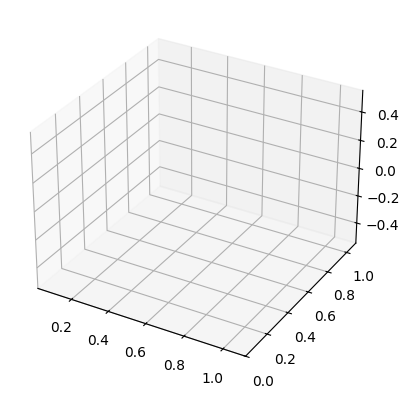

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np 

model_out = model(torch.tensor(mesh_geo.mesh.vertices))[:, :3].detach()

x, y, z = mesh_geo.mesh.vertices[:, 0], mesh_geo.mesh.vertices[:, 1], mesh_geo.mesh.vertices[:, 2]
u, v, w = model_out[:, 0], model_out[:, 1], model_out[:, 2]

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.quiver(
    x, y, z,
    u, v, w,
    length=2.0
)

mid_x = (x.max() + x.min()) * 0.5
mid_y = (y.max() + y.min()) * 0.5
mid_z = (z.max() + z.min()) * 0.5

max_range = (
    np.array([x.max() - x.min(), y.max() - y.min(), z.max() - z.min()]).max() / 2.0
)

ax.set_xlim(mid_x - max_range, mid_x + max_range)
ax.set_ylim(mid_y - max_range, mid_y + max_range)
ax.set_zlim(mid_z - max_range, mid_z + max_range)

plt.show()